## 1a. Выбор набора данных и обоснование
Используется датасет **Smoking/Non-Smoking Classification**. 
**Практическая ценность:** Автоматическое детектирование курения применяется в системах контроля безопасности на АЗС, складах, в общественных местах и на промышленных объектах для предотвращения пожаров и соблюдения норм охраны труда. Задача бинарной классификации изображений хорошо ложится на современные CV-пайплайны и позволяет продемонстрировать работу transfer learning и обучения с нуля.

## 1b. Выбор метрик и обоснование
Помимо `Accuracy` используются:
- `Precision` → минимизация ложных срабатываний (важно, чтобы система не штрафовала некурящих)
- `Recall` → минимизация пропусков (критично для безопасности: пропуск курения = риск пожара)
- `F1-score` → гармоническое среднее, дает сбалансированную оценку при возможном дисбалансе классов
- `Confusion Matrix` → наглядная визуализация типов ошибок модели

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob

from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm

print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/dench/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


PyTorch: 2.10.0+cu128 | CUDA: True


In [2]:
PATH = 'data'
NUM_EPOCHS_BASELINE = 15
NUM_EPOCHS_IMPROVED = 10

class SmokingDataset(Dataset):
    def __init__(self, split, transform=None):
        mapping = {'train': 'Training', 'validation': 'Validation', 'test': 'Testing'}
        data_path = mapping[split]
        self.root = os.path.join(PATH, data_path)
        self.transform = transform
        self.classes = {"notsmoking": 0, "smoking": 1}
        
        self.image_paths = []
        self.labels = []
        
        for status, label in self.classes.items():
            self.image_paths.extend(glob.glob(f"{self.root}/{status}*.jpg"))
            self.labels.extend([label] * len(glob.glob(f"{self.root}/{status}*.jpg")))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

In [3]:
transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [4]:
train_data = SmokingDataset('train', transform=transform_train)
val_data = SmokingDataset('validation', transform=transform_val_test)
test_data = SmokingDataset('test', transform=transform_val_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

In [5]:
def compute_metrics(model, dataloader, criterion):
    model.eval()
    all_preds, all_labels = [], []
    total_loss, correct = 0.0, 0
    
    with torch.no_grad():
        for imgs, lbls in tqdm(dataloader, desc="Evaluating", leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            outs = model(imgs)
            loss = criterion(outs, lbls)
            preds = outs.argmax(dim=1)
            
            total_loss += loss.item() * imgs.size(0)
            correct += (preds == lbls).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    avg_loss = total_loss / len(dataloader.dataset)
    
    return {"Loss": avg_loss, "Acc": acc, "Precision": prec, "Recall": rec, "F1": f1}

def train_model(model, train_dl, val_dl, epochs, optimizer, scheduler, criterion, name="Model"):
    history = []
    best_val_acc = 0
    for ep in range(epochs):
        model.train()
        ep_loss, correct, total = 0.0, 0, 0
        for imgs, lbls in tqdm(train_dl, desc=f"{name} Ep {ep+1}/{epochs}", leave=True):
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outs = model(imgs)
            loss = criterion(outs, lbls)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
            correct += (outs.argmax(1) == lbls).sum().item()
            total += lbls.size(0)
            
        train_acc = correct / total
        
        val_metrics = compute_metrics(model, val_dl, criterion)
        
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_metrics["Acc"])
            else:
                scheduler.step()
                
        history.append({"epoch": ep+1, "train_loss": ep_loss/len(train_dl), "train_acc": train_acc, **val_metrics})
        
        if val_metrics["Acc"] > best_val_acc:
            best_val_acc = val_metrics["Acc"]
            
    return history, best_val_acc

In [6]:
class BaselineResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)
        for p in self.backbone.parameters(): p.requires_grad = False
        self.backbone.fc = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.3), nn.Linear(512, 2))
    def forward(self, x): return self.backbone(x)

model_resnet = BaselineResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer_res = optim.Adam(model_resnet.backbone.fc.parameters(), lr=1e-3)
sch_res = optim.lr_scheduler.ReduceLROnPlateau(optimizer_res, mode='max', patience=3)

hist_res, _ = train_model(model_resnet, train_loader, val_loader, NUM_EPOCHS_BASELINE, optimizer_res, sch_res, criterion, "ResNet-Base")

ResNet-Base Ep 15/15: 100%|█████████████████████████████████████████████████████████████| 23/23 [00:04<00:00,  5.59it/s]
                                                                                                                        

In [7]:
class BaselineViT(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.vit_b_16(weights=torchvision.models.ViT_B_16_Weights.IMAGENET1K_V1)
        for p in self.backbone.parameters(): p.requires_grad = False
        self.backbone.heads.head = nn.Sequential(nn.Linear(768, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, 2))
    def forward(self, x): return self.backbone(x)

model_vit = BaselineViT().to(device)
optimizer_vit = optim.Adam(model_vit.backbone.heads.head.parameters(), lr=1e-3)
sch_vit = optim.lr_scheduler.ReduceLROnPlateau(optimizer_vit, mode='max', patience=3)

hist_vit, _ = train_model(model_vit, train_loader, val_loader, NUM_EPOCHS_BASELINE, optimizer_vit, sch_vit, criterion, "ViT-Base")

ViT-Base Ep 15/15: 100%|████████████████████████████████████████████████████████████████| 23/23 [00:24<00:00,  1.07s/it]
                                                                                                                        

## 3. Улучшение бейзлайна
**Гипотезы:**
1. `Разморозка последних блоков (layer4 для ResNet)` → предобученные фичи уже содержат низкоуровневые паттерны, тонкая настройка высокоуровневых признаков адаптирует модель под специфику сигарет/рук.
2. `AdamW + CosineAnnealingLR` → AdamW лучше контролирует весовой decay, косинусное расписание избегает резких скачков lr в конце обучения.
3. `Усиленные аугментации` → `RandomErasing` + `GaussianBlur` повышают робастность к шумам и частичным окклюзиям.

In [8]:
class ImprovedResNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V1)
        for p in list(self.backbone.parameters())[:-len(list(self.backbone.layer4.parameters()))]:
            p.requires_grad = False
        self.backbone.fc = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.4), nn.Linear(512, 2))
    def forward(self, x): return self.backbone(x)

model_imp = ImprovedResNet().to(device)
optimizer_imp = optim.AdamW(filter(lambda p: p.requires_grad, model_imp.parameters()), lr=2e-4)
scheduler_imp = optim.lr_scheduler.CosineAnnealingLR(optimizer_imp, T_max=15)

hist_imp, _ = train_model(model_imp, train_loader, val_loader, NUM_EPOCHS_IMPROVED, optimizer_imp, scheduler_imp, criterion, "ResNet-Imp")

ResNet-Imp Ep 10/10: 100%|██████████████████████████████████████████████████████████████| 23/23 [00:05<00:00,  4.19it/s]
                                                                                                                        

In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.5), nn.Linear(128, 2))
    def forward(self, x): return self.classifier(self.features(x))

model_scratch = SimpleCNN().to(device)
opt_scr = optim.Adam(model_scratch.parameters(), lr=1e-3)
hist_scr, _ = train_model(model_scratch, train_loader, val_loader, NUM_EPOCHS_BASELINE, opt_scr, None, criterion, "Scratch")

Scratch Ep 15/15: 100%|█████████████████████████████████████████████████████████████████| 23/23 [00:03<00:00,  6.50it/s]
                                                                                                                        

In [14]:
opt_scr_imp = optim.AdamW(model_scratch.parameters(), lr=1e-3)
sch_scr_imp = optim.lr_scheduler.CosineAnnealingLR(opt_scr_imp, T_max=15)
hist_scr_imp, _ = train_model(model_scratch, train_loader, val_loader, NUM_EPOCHS_IMPROVED, opt_scr_imp, sch_scr_imp, criterion, "Scratch-Imp")

Scratch-Imp Ep 10/10: 100%|█████████████████████████████████████████████████████████████| 23/23 [00:03<00:00,  6.27it/s]
                                                                                                                        

In [15]:
models_eval = {
    "ResNet-Base": model_resnet,
    "ViT-Base": model_vit,
    "ResNet-Imp": model_imp,
    "Scratch": model_scratch, 
    "Scratch-Imp": SimpleCNN().to(device)
}
models_eval = {"ResNet-Base": model_resnet, "ViT-Base": model_vit, "ResNet-Imp": model_imp, "Scratch": model_scratch} 

results = {}
for name, m in models_eval.items():
    results[name] = compute_metrics(m, test_loader, criterion)

df = pd.DataFrame(results).T
df.index.name = "Model"
print(df.round(4))

               Loss     Acc  Precision  Recall      F1
Model                                                 
ResNet-Base  0.2567  0.8929     0.8860  0.9018  0.8938
ViT-Base     0.1026  0.9598     0.9402  0.9821  0.9607
ResNet-Imp   0.1916  0.9464     0.9310  0.9643  0.9474
Scratch      0.5477  0.7143     0.7264  0.6875  0.7064


Best model by F1: ViT-Base


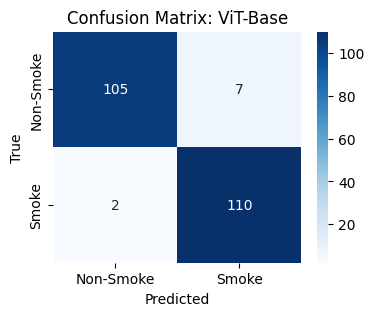

In [16]:
best_model = max(results, key=lambda k: results[k]["F1"])
print(f"Best model by F1: {best_model}")

m = models_eval[best_model]
m.eval()
preds, trues = [], []
with torch.no_grad():
    for x, y in test_loader:
        outs = m(x.to(device))
        preds.extend(outs.argmax(1).cpu().numpy())
        trues.extend(y.numpy())

cm = confusion_matrix(trues, preds)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Smoke','Smoke'], yticklabels=['Non-Smoke','Smoke'])
plt.ylabel('True'); plt.xlabel('Predicted')
plt.title(f'Confusion Matrix: {best_model}')
plt.show()